In [67]:
import numpy as np
import matplotlib.pyplot as plt


Student 1: [Nina Gumbs], [6552544]
Student 2: [Luuk van Dijk], [651702]
Student 3: [Jens Groen], [6353991]

In [68]:
#Constanten
mu0 = 4*np.pi*10**-7

Dipool benadering Magneetveld circulaire halbach array

flux_kwadraat boven, Parallel, magneten: 9.544766953093437e-06 Wb
flux_kwadraat boven, Parallel, magneten: 9.544766953093437e-06 Wb
flux_kwadraat boven, Halbach, magneten: 4.5200546961182154e-06 Wb
flux_kwadraat onder, Halbach, magneten: 1.2536701337747777e-05 Wb
flux_kwadraat boven, Chat Halbach, magneten: 7.537448359051197e-06 Wb
flux_kwadraat onder, Chat Halbach, magneten: 7.5374483590512e-06 Wb


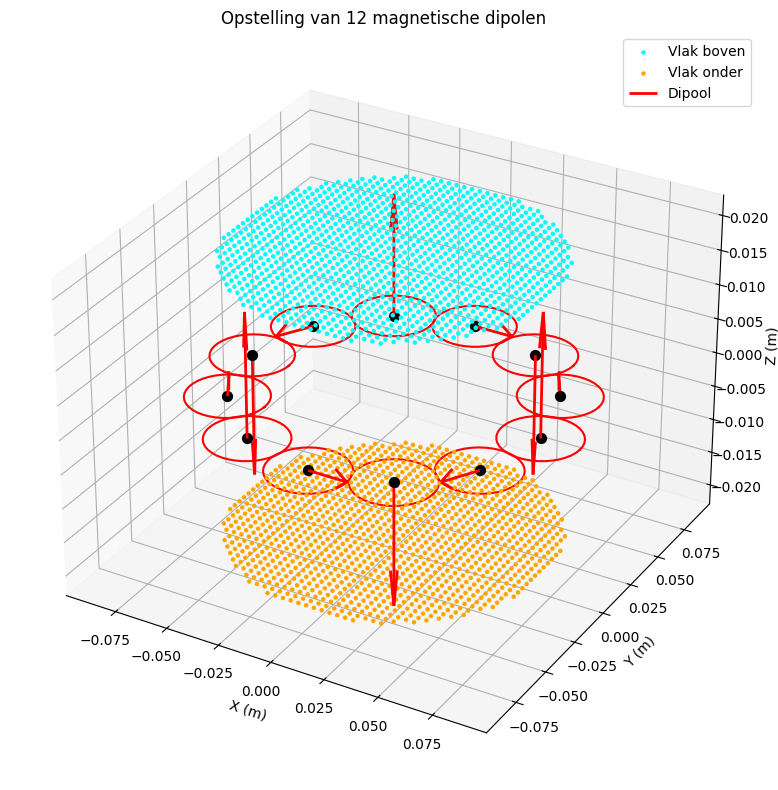

In [69]:
#########inputs#########

# aantal magneten
N = 12



#Magneet waardes
rmag = 18*10**-3
Amag = np.pi *rmag**2
hmag =  3*10**-3
Br = 1.265 # N35 ~ N45 
p = 3 #draaingrichting en snelheid van hoek van de magneten


# radius
r    = N*rmag/np.pi

#Configuratie van de magneten
configuratie_namen = {
    0: "Halbach",
    1: "Parallel",
    2: "Radiaal",
    3: "Chat Halbach"
}

configuratie = 0 
configuratie2 = 3 
################flux_kwadraat################

#flux_kwadraatvlak 1
xo1 = 0
yo1 = 0
n1 = 40  # grid resolution
width1 = r*2.1
z_plane1 = 0.02

#flux_kwadraatvlak 2 gespiegeld op het x-y vlak
xo2 = xo1
yo2 = yo1
n2 = n1  # grid resolution
width2 = width1
z_plane2 = -z_plane1




##############Berekeningen##########


conf = configuratie_namen[configuratie]
conf2 = configuratie_namen[configuratie2]
def m(theta,conf,p):
    V = Amag * hmag
    m = (Br * V)/mu0*Magnetenrichting(theta,conf,p)
    return m

def Magnetenrichting(theta,conf,p):
    alpha = p * theta
    z_hat = np.array([0, 0, 1]) 
    r_hat = np.array([np.cos(theta), np.sin(theta), 0])
    nu_hat = np.array([-np.sin(theta), np.cos(theta), 0])

    if conf == "Halbach":
        phi = np.sin(alpha) * nu_hat + np.cos(alpha) * z_hat 
    if conf == "Parallel":
        phi = z_hat
    if conf == "Radiaal":
        phi = r_hat
    if conf == "Chat Halbach":
        phi = np.sin(alpha) * r_hat + np.cos(alpha) * z_hat
    return phi

def Magnetenpositie(r,theta):
    z = 0
    rdak = np.array([r*np.cos(theta),r*np.sin(theta),z])
    return rdak

def Bveld(r,rpunt,conf,p,N):
    Btot = np.zeros(3)
    for i in range(N):
        theta = 2*np.pi*i/N
        mag = m(theta,conf,p)
        R = rpunt - Magnetenpositie(r,theta) #vector van magneet naar meetpunt
        Rdakje = R/np.linalg.norm(R)
        B = mu0/(4*np.pi*np.linalg.norm(R)**3)*(3*np.dot(mag, Rdakje)*Rdakje - mag) 
        Btot = B + Btot
    return Btot

def maak_vlak_cirkel(width, z_plane, n=40, x_offset=0, y_offset=0):
    r_max = width / 2
    x = np.linspace(-r_max + x_offset, r_max + x_offset, n)
    y = np.linspace(-r_max + y_offset, r_max + y_offset, n)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    
    punten = []
    for xi in x:
        for yi in y:
            # Alleen punten binnen de cirkel
            if (xi - x_offset)**2 + (yi - y_offset)**2 <= r_max**2:
                rpunt = np.array([xi, yi, z_plane])
                punten.append((rpunt, dx, dy))
    
    return punten, x, y


def flux_kwadraat(meetpunten, conf, p, N):
    """Integreert Bz² over het vlak — correct voor liftkracht"""
    total = 0
    for rpunt, dx, dy in meetpunten:
        B = Bveld(r, rpunt, conf, p, N)
        total += B[2]**2 * dx * dy
    return total

# Vlak boven de magneten
vlak_boven,  x1, y1 = maak_vlak_cirkel(width1, z_plane1,n1, xo1,yo1)
vlak_onder,  x2, y2 = maak_vlak_cirkel(width2, z_plane2,n2, xo2, yo2)

print("flux_kwadraat boven, Parallel, magneten:", flux_kwadraat(vlak_boven,"Parallel", p,N), "Wb")
print("flux_kwadraat boven, Parallel, magneten:", flux_kwadraat(vlak_onder,"Parallel", p,N), "Wb")
print("flux_kwadraat boven, "+ conf +", magneten:", flux_kwadraat(vlak_boven,conf, p,N), "Wb")
print("flux_kwadraat onder, " + conf +  ", magneten:", flux_kwadraat(vlak_onder,conf,p,N), "Wb")
print("flux_kwadraat boven, "+ conf2 +", magneten:", flux_kwadraat(vlak_boven,conf2, p,N), "Wb")
print("flux_kwadraat onder, " + conf2 +  ", magneten:", flux_kwadraat(vlak_onder,conf2,p,N), "Wb")




#######plotting########

def plot_vlak(ax, punten, color='cyan', alpha=1, label=''):
    """Plot de gridpunten van maak_vlak_cirkel als stippen in 3D."""
    xs = [p[0][0] for p in punten]
    ys = [p[0][1] for p in punten]
    zs = [p[0][2] for p in punten]
    ax.scatter(xs, ys, zs, color=color, alpha=alpha, s=5, label=label)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

#Vlak
plot_vlak(ax, vlak_boven, color='cyan',   label='Vlak boven')
plot_vlak(ax, vlak_onder, color='orange', label='Vlak onder')



#magneten
for i in range(N):
    theta    = 2 * np.pi * i / N
    pos      = Magnetenpositie(r, theta)
    richting = Magnetenrichting(theta, conf, p)

    # Cirkel (schijf) plat in het x-y vlak
    theta_cil = np.linspace(0, 2 * np.pi, 40)
    xc = pos[0] + rmag * np.cos(theta_cil)
    yc = pos[1] + rmag * np.sin(theta_cil)
    zc = np.full_like(xc, pos[2])
    ax.plot(xc, yc, zc, color='red', linewidth=1.5)

    # Pijl
    ax.quiver(*pos, *richting, length=rmag, color='red',
              linewidth=2, label='Dipool' if i == 0 else "")

    ax.scatter(*pos, color='black', s=50, zorder=5)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title(f'Opstelling van {N} magnetische dipolen')
ax.legend()
plt.tight_layout()
plt.show()


flux_kwadraat boven, Parallel: 9.768854679142086e-07
flux_kwadraat onder, Parallel: 9.768854679142086e-07
flux_kwadraat boven, Halbach: 1.5392895529408824e-08
flux_kwadraat onder, Halbach: 1.0030711113791558e-06
flux_kwadraat boven, Chat Halbach: 3.014421341940963e-07
flux_kwadraat onder, Chat Halbach: 3.014421341940966e-07


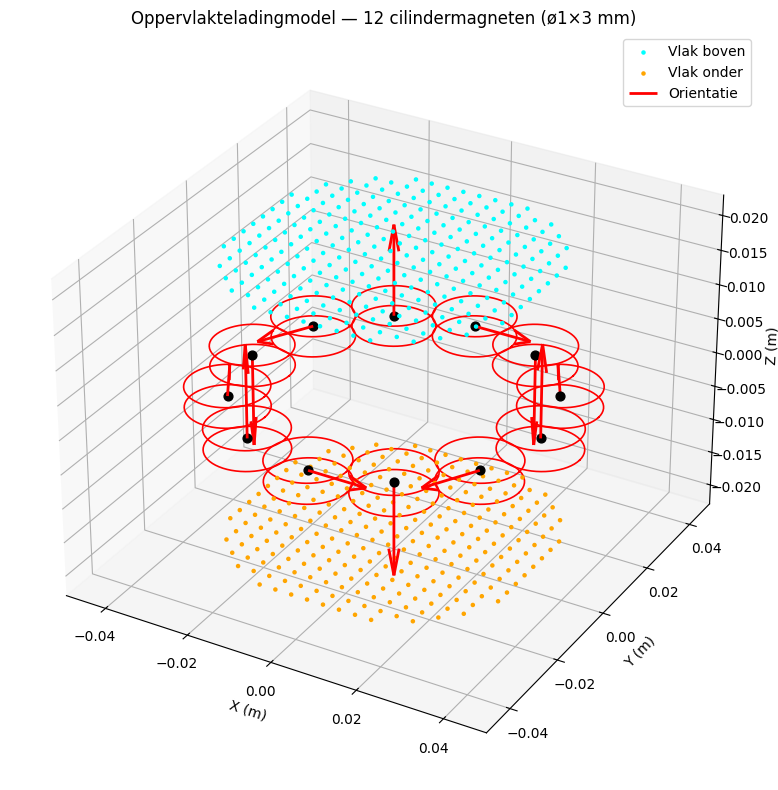

In [72]:
#########inputs#########
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate

mu0 = 4 * np.pi * 1e-7

# aantal magneten
N = 12

# Magneet waardes
rmag = 18e-3 / 2      # straal = 9 mm
hmag = 3e-3            # hoogte = 3 mm
Br = 1.265             # N35~N45
p = 3

# radius van de ring
r = N * rmag / np.pi

configuratie_namen = {
    0: "Halbach",
    1: "Parallel",
    2: "Radiaal",
    3: "Chat Halbach"
}
configuratie  = 0
configuratie2 = 3

conf  = configuratie_namen[configuratie]
conf2 = configuratie_namen[configuratie2]

# ──────────────────────────────────────────────
# Surface charge model voor een cilindermagneet
# ──────────────────────────────────────────────
# sigma_m = Br / mu0  (oppervlakteladingsdichtheid op de platte vlakken)
# B = mu0/(4pi) ∫ sigma_m * (r-r') / |r-r'|^3 dA'
# De bovenkant (z = +h/2) heeft +sigma_m, de onderkant (z = -h/2) heeft -sigma_m.
# We integreren numeriek over beide schijven in poolcoördinaten.

N_RING = 12//2     # radiale integratiepunten per schijf
N_ANG  = 36//2     # hoekintegratiepunten per schijf

def _disk_field(obs, center, normal_sign, R, sigma_m, n_ring=N_RING, n_ang=N_ANG):
    """
    Bijdrage van één geladen schijf aan het B-veld in obs.
    center : middelpunt van de schijf (3-vector)
    normal_sign : +1 (bovenkant) of -1 (onderkant)
    R      : straal van de schijf
    sigma_m: mu_0-vrije oppervlakteladingsdichtheid = Br/mu0
    """
    rho_vals = np.linspace(0, R, n_ring + 1)[1:]        # vermijd rho=0
    dphi     = 2 * np.pi / n_ang
    drho     = R / n_ring

    B = np.zeros(3)
    for rho in rho_vals:
        for k in range(n_ang):
            phi = (k + 0.5) * dphi
            src = center + np.array([rho * np.cos(phi), rho * np.sin(phi), 0.0])
            Rvec = obs - src
            dist = np.linalg.norm(Rvec)
            if dist < 1e-9:
                continue
            dA = rho * drho * dphi
            B += (mu0 / (4 * np.pi)) * normal_sign * sigma_m * Rvec / dist**3 * dA
    return B


def B_cylinder(obs, pos, orientation, R, h, Br):
    """
    Veld van één cilindermagneet via het oppervlakteladingmodel.

    obs         : meetpunt (3-vector)
    pos         : middelpunt van de magneet (3-vector)
    orientation : eenheidsvector van de magnetisatierichting (3-vector)
    R           : straal
    h           : hoogte
    Br          : remanentie [T]
    """
    sigma_m = Br / mu0

    # Lokale coördinaten: de magneet as wijst langs 'orientation'
    # Boven-midden en onder-midden in lab-coördinaten
    top_center = pos + (h / 2) * orientation
    bot_center = pos - (h / 2) * orientation

    # We bouwen een lokaal assenstelsel zodat we de schijven correct kunnen
    # positioneren. Omdat we toch in lab-coördinaten integreren (de schijven
    # liggen loodrecht op orientation), moeten we de bron-positie uitdrukken
    # in het vlak loodrecht op orientation.

    # Kies twee basisvectoren loodrecht op orientation
    oz = orientation
    # Kies een willekeurige vector die niet evenwijdig is aan oz
    helper = np.array([1, 0, 0]) if abs(oz[0]) < 0.9 else np.array([0, 1, 0])
    ox = np.cross(oz, helper); ox /= np.linalg.norm(ox)
    oy = np.cross(oz, ox)

    def disk_B(center, sign):
        rho_vals = np.linspace(0, R, N_RING + 1)[1:]
        dphi = 2 * np.pi / N_ANG
        drho = R / N_RING
        B = np.zeros(3)
        for rho in rho_vals:
            for k in range(N_ANG):
                phi = (k + 0.5) * dphi
                src = center + rho * (np.cos(phi) * ox + np.sin(phi) * oy)
                Rvec = obs - src
                dist = np.linalg.norm(Rvec)
                if dist < 1e-9:
                    continue
                dA = rho * drho * dphi
                B += (mu0 / (4 * np.pi)) * sign * sigma_m * Rvec / dist**3 * dA
        return B

    return disk_B(top_center, +1) + disk_B(bot_center, -1)


# ──────────────────────────────────────────────
# Magneetconfiguraties  (zelfde als origineel)
# ──────────────────────────────────────────────

def Magnetenrichting(theta, conf, p):
    alpha = p * theta
    r_hat  = np.array([ np.cos(theta),  np.sin(theta), 0.0])  # 0.0 not 0
    nu_hat = np.array([-np.sin(theta),  np.cos(theta), 0.0])
    z_hat  = np.array([0.0, 0.0, 1.0])

    if conf == "Halbach":
        return np.sin(alpha) * nu_hat + np.cos(alpha) * z_hat
    if conf == "Parallel":
        return z_hat
    if conf == "Radiaal":
        return r_hat
    if conf == "Chat Halbach":
        return np.sin(alpha) * r_hat + np.cos(alpha) * z_hat

def Magnetenpositie(r, theta):
    return np.array([r * np.cos(theta), r * np.sin(theta), 0.0])


def Bveld(r, rpunt, conf, p, N):
    Btot = np.zeros(3)
    for i in range(N):
        theta = 2 * np.pi * i / N
        pos   = Magnetenpositie(r, theta)
        ori   = Magnetenrichting(theta, conf, p)
        Btot += B_cylinder(rpunt, pos, ori, rmag, hmag, Br)
    return Btot


# ──────────────────────────────────────────────
# Vlakken en flux_kwadraat  (zelfde interface)
# ──────────────────────────────────────────────

def maak_vlak_cirkel(width, z_plane, n=40, x_offset=0, y_offset=0):
    r_max = width / 2
    x = np.linspace(-r_max + x_offset, r_max + x_offset, n)
    y = np.linspace(-r_max + y_offset, r_max + y_offset, n)
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    punten = []
    for xi in x:
        for yi in y:
            if (xi - x_offset)**2 + (yi - y_offset)**2 <= r_max**2:
                punten.append((np.array([xi, yi, z_plane]), dx, dy))
    return punten, x, y


def flux_kwadraat(meetpunten, conf, p, N):
    total = 0
    for rpunt, dx, dy in meetpunten:
        B = Bveld(r, rpunt, conf, p, N)
        total += B[2]**2 * dx * dy
    return total


# ──────────────────────────────────────────────
# Vlak instellingen
# ──────────────────────────────────────────────
xo1, yo1 = 0, 0
n1       = 20          # lager voor snelheid; verhoog naar 40 voor precisie
width1   = r * 2.1
z_plane1 = 0.02

vlak_boven, x1, y1 = maak_vlak_cirkel(width1,  z_plane1, n1, xo1, yo1)
vlak_onder, x2, y2 = maak_vlak_cirkel(width1, -z_plane1, n1, xo1, yo1)

print("flux_kwadraat boven, Parallel:",   flux_kwadraat(vlak_boven, "Parallel", p, N))
print("flux_kwadraat onder, Parallel:",   flux_kwadraat(vlak_onder, "Parallel", p, N))
print(f"flux_kwadraat boven, {conf}:",    flux_kwadraat(vlak_boven,  conf,  p, N))
print(f"flux_kwadraat onder, {conf}:",    flux_kwadraat(vlak_onder,  conf,  p, N))
print(f"flux_kwadraat boven, {conf2}:",   flux_kwadraat(vlak_boven,  conf2, p, N))
print(f"flux_kwadraat onder, {conf2}:",   flux_kwadraat(vlak_onder,  conf2, p, N))


# ──────────────────────────────────────────────
# Plot
# ──────────────────────────────────────────────
def plot_vlak(ax, punten, color='cyan', alpha=1, label=''):
    xs = [p[0][0] for p in punten]
    ys = [p[0][1] for p in punten]
    zs = [p[0][2] for p in punten]
    ax.scatter(xs, ys, zs, color=color, alpha=alpha, s=5, label=label)

fig = plt.figure(figsize=(10, 8))
ax  = fig.add_subplot(111, projection='3d')

plot_vlak(ax, vlak_boven, color='cyan',   label='Vlak boven')
plot_vlak(ax, vlak_onder, color='orange', label='Vlak onder')

for i in range(N):
    theta = 2 * np.pi * i / N
    pos   = Magnetenpositie(r, theta)
    ori   = Magnetenrichting(theta, conf, p)

    # Teken cilinder-omtrek op boven- en onderkant
    for dz in [+hmag/2, -hmag/2]:
        tc = np.linspace(0, 2*np.pi, 60)
        xc = pos[0] + rmag * np.cos(tc)
        yc = pos[1] + rmag * np.sin(tc)
        zc = np.full_like(xc, pos[2] + dz)
        ax.plot(xc, yc, zc, color='red', linewidth=1.2)

    # Pijl voor magnetisatierichting
    ax.quiver(*pos, *ori, length=rmag*1.5, color='red',
              linewidth=2, label='Orientatie' if i == 0 else "")
    ax.scatter(*pos, color='black', s=40, zorder=5)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')
ax.set_title(f'Oppervlakteladingmodel — {N} cilindermagneten (ø{int(rmag*2000/10)}×{int(hmag*1000)} mm)')
ax.legend()
plt.tight_layout()
plt.show()

## Eddy-Current Lift Force — Afleiding

### 1. flux_kwadraat door de plaat
$$\Phi(A) = \iint_{A} B_z \, dA$$

### 2. Wet van Faraday
$$\mathcal{E} = \Phi(A) \cdot \omega$$

### 3. Weerstand van de plaat
$$R = \frac{1}{\sigma} \cdot \frac{t}{A}$$

### 4. Geïnduceerde stroom
$$I = \frac{\mathcal{E}}{R} = \frac{\sigma \cdot A \cdot \Phi(A) \cdot \omega}{t}$$

### 5. Liftkracht (Lorentz)
$$F_{lift} = I \cdot \Phi(A) = \frac{\sigma \cdot A}{t} \cdot \Phi(A)^2 \cdot \omega^2$$

### 6. Zwaartekracht
$$F_z = \rho \cdot A \cdot t \leq g$$

### 7. Levitatieconditie
$$F_{lift} > F_z$$

$$\frac{\sigma \cdot A}{t} \cdot \Phi(A)^2 \cdot \omega^2 > \rho \cdot A \cdot t \cdot g$$

### 8. Kritische hoeksnelheid
$$\boxed{\omega_{min} = \sqrt{\frac{\rho \cdot t^2 \cdot g}{\sigma \cdot \Phi(A)^2}}}$$

## $\omega_{min}$ hangt af van $\Phi(A)$ — kleine platen vangen minder flux_kwadraat op,
## dus hebben hogere $\omega$ nodig. Grote platen (groter dan het magneetpatroon) verzadigen in flux_kwadraat.

KeyboardInterrupt: 

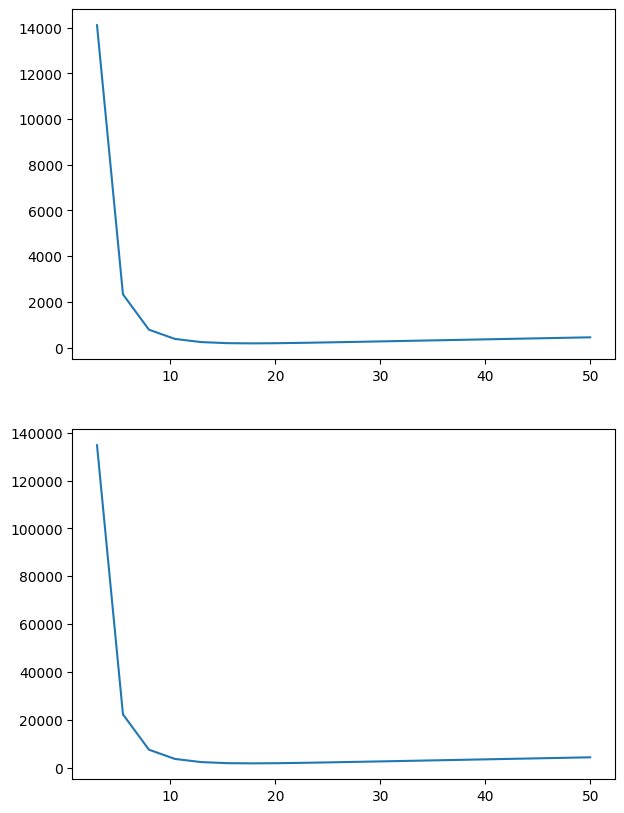

In [ ]:
# ── Constanten ───────────────────────────────────────────────
config = 1
sigma = 6e7
rho_m = 8960
g     = 9.81
t     = 0.003

# ── Parameters ───────────────────────────────────────────────
N_vals     = 12
width_vals = np.linspace(0.03, 0.5, 20)
width_cm   = width_vals * 100
n_flux_kwadraat = 30
z_plaat = np.linspace(0.05, 0.1, 10)



conf = configuratie_namen[configuratie]
# ── Figure met 2 subplots ────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 10))

for Z in z_plaat:
    omega_min_vals = []
    RPM_min_vals   = []
    
    for w in width_vals:
        vlak  = maak_vlak_cirkel(w, Z, n_flux_kwadraat, xo1, yo1)[0]
        Phi2  = flux_kwadraat(vlak, conf, p, N)
        A     = w**2
        Bz    = np.sqrt(Phi2 / A)
        
        if Bz > 1e-6:
            omega_min = np.sqrt((rho_m * g) / (sigma * t * Bz**2))
            RPM       = omega_min * 60 / (2 * np.pi)
        else:
            omega_min = np.nan
            RPM       = np.nan
        
        omega_min_vals.append(omega_min)
        RPM_min_vals.append(RPM)
    
    # plot beide
    ax1.plot(width_cm, omega_min_vals, label=f"Z={Z}")
    ax2.plot(width_cm, RPM_min_vals, label=f"Z={Z}")

# ── Opmaak ───────────────────────────────────────────────────
ax1.set_xlabel("Plaatbreedte [cm]")
ax1.set_ylabel("Hoeksnelheid ω [rad/s]")
ax1.legend()
ax1.grid(True)
ax1.set_ylim(0, 1000)

ax2.set_xlabel("Plaatbreedte [cm]")
ax2.set_ylabel("Hoeksnelheid RPM [rot/min]")
ax2.legend()
ax2.grid(True)
ax2.set_ylim(0, 10000)


plt.tight_layout()
plt.show()

Om te bepalen bij welke rotatiesnelheid de Halbach-array een koperen plaat kan laten
levitieren, wordt het evenwicht tussen liftkracht en zwaartekracht opgesteld:

  ω_min = sqrt( ρ_m · g / (σ · t · <Bz²>) )

Uit de grafiek volgt dat bij Z = 5 cm een minimum bereikt wordt rond w ≈ 7 cm,
met ω_min ≈ 230 rad/s ≈ 2200 RPM. Dit is haalbaar met een standaard BLDC-motor
en toont aan dat levitatie met deze opstelling demonstreerbaar is.

Bij grotere plaat (w > 10 cm) neemt ω_min weer toe: de plaat steekt buiten het
effectieve veldgebied van de array (diameter 2r = 6,8 cm), waardoor <Bz²> daalt.
Bij kleinere plaat mist een deel van de flux het plaatoppervlak.
Het optimum ligt dus rond w ≈ 2r.

Bij grotere hoogte Z neemt ω_min sterk toe door de exponentiële veldafval,
en worden de curves buiten het plotvenster (> 1000 rad/s) geclipped.